<a href="https://colab.research.google.com/github/AbhishekNegiCode/Global-Energy-Transition-Analysis/blob/main/Global_Energy_Sustainable_Development_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Energy & Sustainable Development: A Data-Driven Analysis

This non-machine-learning project investigates global energy demand, energy sources, renewable deployment, fossil-fuel dependence, climate indicators and India’s energy transition using the Our World in Data Energy Dataset. It supports evidence-led discussion of **SDG 7 — Affordable and Clean Energy** and **SDG 13 — Climate Action**. The analysis describes patterns in reported data; it does not prove causation or make predictions.

**Workflow:** Data collection → understanding → quality assessment → cleaning → transformation → EDA → statistical analysis → Matplotlib visualization → insight extraction → sustainability interpretation.

## 1. Import libraries

**Why:** Pandas manages tabular data, NumPy supports numerical calculations, and Matplotlib creates the primary charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')

**Expected interpretation:** The imports should run without errors. This establishes a reproducible analytical environment.

## 2. Data collection and loading

Upload the CSV supplied by OWID. The code finds the uploaded CSV even if Colab changes its filename.

In [2]:
uploaded = files.upload()
csv_files = [name for name in uploaded if name.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError('Please upload owid-energy-data.csv.')
file_name = 'owid-energy-data.csv' if 'owid-energy-data.csv' in csv_files else csv_files[0]
df = pd.read_csv(file_name, low_memory=False)
print(f'Loaded: {file_name}')
display(df.head())
display(df.tail())

Saving owid-energy-data.csv to owid-energy-data (1).csv
Loaded: owid-energy-data (1).csv


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.87,1.549794,NaN,572.580017,NaN,NaN,NaN,NaN,NaN,76.029999,NaN,NaN,NaN,NaN,20.073397,NaN,378.760010,NaN,378.760010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305.529999,NaN,NaN,80.665855,NaN,NaN,NaN,NaN,NaN,164.259995,NaN,NaN,NaN,NaN,NaN,43.367828,NaN,216.869995,NaN,NaN,NaN,NaN,50.430000,NaN,13.314500,NaN,NaN,NaN,NaN,NaN,73.230003,NaN,19.334143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,65.239998,NaN,NaN,NaN,NaN,NaN,17.224627,NaN,NaN,22.799999,16.930000,NaN,NaN,NaN,NaN,NaN,6.019643,4.469849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.230003,NaN,19.334143,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.46,1.594707,NaN,570.270020,NaN,NaN,NaN,NaN,NaN,86.260002,NaN,NaN,NaN,NaN,21.294035,NaN,405.089996,NaN,405.089996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,327.899994,NaN,NaN,80.944977,NaN,NaN,NaN,NaN,NaN,190.410004,NaN,NaN,NaN,NaN,NaN,47.004372,NaN,231.009995,NaN,NaN,NaN,NaN,54.330002,NaN,13.411835,NaN,NaN,NaN,NaN,NaN,77.190002,NaN,19.055025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,51.230000,NaN,NaN,NaN,NaN,NaN,12.646572,NaN,NaN,22.860001,16.

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
23372,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,NaN,0.0,0.0,0.0,6.440441,0.10,1.490313,NaN,371.089996,NaN,NaN,NaN,NaN,176.468079,2.74,3.004352,0.591858,1306.886353,20.291876,40.834576,NaN,8.69,559.674316,6.71,NaN,-15.539186,-6.179134,2163.068359,1.448990,NaN,NaN,179.044266,2.78,NaN,NaN,41.430698,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2.49,NaN,NaN,NaN,245.380798,3.81,NaN,56.780922,NaN,NaN,NaN,NaN,253.109329,3.93,NaN,58.569302,NaN,1.98,22.784811,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,2.576176,0.04,NaN,NaN,NaN,NaN,NaN,0.596125,NaN,NaN,0.10,0.0,NaN,NaN,6.440441,0.0,NaN,1.490313,0.0,NaN,432.153595,33.585716,NaN,NaN,NaN,253.109329,3.93,NaN,58.569302,NaN,NaN,NaN,NaN,1.288088,0.02,NaN,0.298063,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23373,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,NaN,0.0,0.0,0.0,6.963251,0.11,1.283547,NaN,269.549988,NaN,NaN,NaN,NaN,158.888718,2.51,19.707773,3.999077,1537.672607,24.290953,29.288216,NaN,10.31,652.646484,8.57,NaN,12.059059,4.050121,2382.434326,1.497045,NaN,NaN,158.888718,2.51,NaN,NaN,29.288216,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2.31,NaN,NaN,NaN,375.382507,5.93,NaN,69.194870,NaN,NaN,NaN,NaN,383.611786,6.06,NaN,70.7

**Expected interpretation:** `head()` shows the first five observations and `tail()` the last five. Check that the entity and year fields appear as expected before analysing the data.

## 3. Data understanding

These checks document the dataset’s dimensions, schema, types, coverage and descriptive statistics before any cleaning.

In [3]:
print('Shape (rows, columns):', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))
print('\nDataset information:')
df.info()
display(df.describe().T)

entity_col = 'country' if 'country' in df.columns else 'Entity'
year_col = 'year' if 'year' in df.columns else 'Year'
print(f'Unique entities: {df[entity_col].nunique()}')
print(f'Year range: {df[year_col].min()} to {df[year_col].max()}')
print('Example entities:', df[entity_col].drop_duplicates().head(25).tolist())
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical columns ({len(numeric_columns)}):', numeric_columns)
print(f'Categorical columns ({len(categorical_columns)}):', categorical_columns)

requested = {'population':'population', 'GDP':'gdp', 'total energy':'primary_energy_consumption',
             'energy per capita':'energy_per_capita', 'coal':'coal_consumption', 'oil':'oil_consumption',
             'gas':'gas_consumption', 'solar':'solar_consumption', 'wind':'wind_consumption',
             'hydro':'hydro_consumption', 'nuclear':'nuclear_consumption',
             'renewables':'renewables_consumption', 'electricity generation':'electricity_generation',
             'CO2':'co2', 'CO2 per capita':'co2_per_capita'}
availability = pd.DataFrame({'Measure': list(requested.keys()), 'Column': list(requested.values())})
availability['Available'] = availability['Column'].isin(df.columns)
display(availability)
print('Important adaptation:', 'Direct CO2 fields are available.' if 'co2' in df.columns else 'This CSV has no direct CO2 / CO2-per-capita columns. Greenhouse-gas emissions will be used as a clearly labelled alternative if available.')

Shape (rows, columns): (23377, 130)

Column names:
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_

,dtype
country,object
year,int64
iso_code,object
population,float64
gdp,float64
...,...
wind_elec_per_capita,float64
wind_electricity,float64
wind_energy_per_capita,float64
wind_share_elec,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


,count,mean,std,min,25%,50%,75%,max
year,23377.0,1.976239e+03,3.533109e+01,1.900000e+03,1.949000e+03,1.985000e+03,2.005000e+03,2.025000e+03
population,18894.0,1.058587e+08,4.720948e+08,1.776000e+03,1.599088e+06,6.951653e+06,2.581793e+07,8.231613e+09
gdp,11780.0,4.257565e+11,3.507870e+12,1.642060e+08,1.426394e+10,4.357680e+10,1.830576e+11,1.301126e+14
biofuel_cons_change_pct,2070.0,4.347882e+01,2.866723e+02,-1.000000e+02,-9.682869e-01,6.695433e+00,2.332031e+01,6.373062e+03
biofuel_cons_change_twh,7903.0,1.054261e+00,6.641947e+00,-5.908398e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.442899e+02
...,...,...,...,...,...,...,...,...
wind_elec_per_capita,8405.0,7.009375e+01,2.776012e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.195791e+00,4.015416e+03
wind_electricity,9507.0,2.136887e+01,1.275394e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.336000e-01,2.713140e+03
wind_energy_per_capita,5145.0,2.149588e+02,7.338794e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.591401e+01,9.315287e+03
wind_share_elec,7661.0,1.712025e+00,4.962740e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.295767e-01,5.821449e+01


Unique entities: 314
Year range: 1900 to 2025
Example entities: ['ASEAN (Ember)', 'Afghanistan', 'Africa', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Albania', 'Algeria', 'American Samoa', 'Angola', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (EIA)', 'Asia and Oceania (Shift)', 'Australia', 'Australia and New Zealand (EIA)', 'Austria', 'Azerbaijan']
Numerical columns (128): ['year', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_sh

,Measure,Column,Available
0,population,population,True
1,GDP,gdp,True
2,total energy,primary_energy_consumption,True
3,energy per capita,energy_per_capita,True
4,coal,coal_consumption,True
5,oil,oil_consumption,True
6,gas,gas_consumption,True
7,solar,solar_consumption,True
8,wind,wind_consumption,True
9,hydro,hydro_consumption,True


Important adaptation: This CSV has no direct CO2 / CO2-per-capita columns. Greenhouse-gas emissions will be used as a clearly labelled alternative if available.


**Expected interpretation:** Record the reported shape, year range and available measures in your project notes. Do not assume a requested measure exists: the availability table is the evidence for subsequent choices.

## 4. Data quality assessment

Missingness, duplicated observations and invalid values must be assessed before treating any number as zero or removing a row.

,Column,Missing Count,Missing Percentage
5,biofuel_cons_change_pct,21307,91.15
114,solar_cons_change_pct,20862,89.24
73,nuclear_cons_change_pct,20798,88.97
122,wind_cons_change_pct,20579,88.03
96,other_renewables_cons_change_pct,19389,82.94
...,...,...,...
88,oil_prod_change_twh,5648,24.16
90,oil_production,5385,23.04
3,population,4483,19.18
1,year,0,0.00


Exact duplicate rows: 0
Duplicate entity-year combinations: 0
Invalid share values outside 0–100:
renewables_share_energy 0
fossil_share_energy 0
renewables_share_elec 0


,Negative values
population,0
gdp,0
primary_energy_consumption,0
energy_per_capita,0
coal_consumption,0
oil_consumption,0
gas_consumption,0
solar_consumption,0
wind_consumption,0
hydro_consumption,0


<Figure size 1200x500 with 0 Axes>

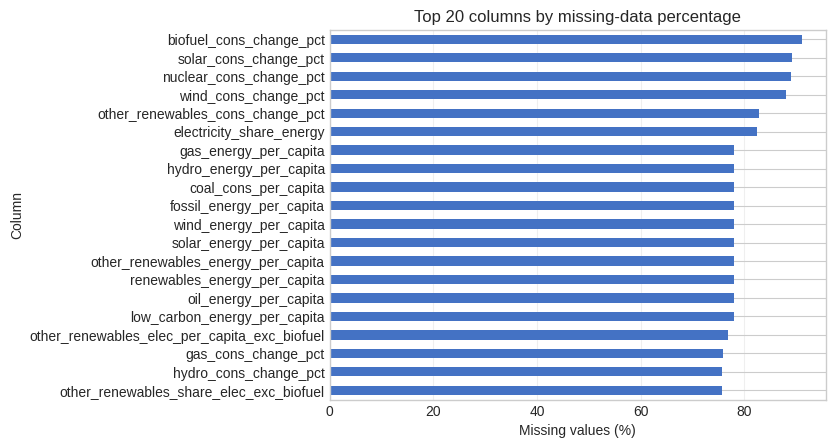

In [4]:
missing_report = pd.DataFrame({'Column': df.columns, 'Missing Count': df.isna().sum().values})
missing_report['Missing Percentage'] = (missing_report['Missing Count'] / len(df) * 100).round(2)
missing_report = missing_report.sort_values('Missing Percentage', ascending=False)
display(missing_report)

print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate entity-year combinations:', df.duplicated([entity_col, year_col]).sum())

important_columns = [c for c in ['population','gdp','primary_energy_consumption','energy_per_capita',
                                  'coal_consumption','oil_consumption','gas_consumption','solar_consumption',
                                  'wind_consumption','hydro_consumption','renewables_consumption',
                                  'fossil_fuel_consumption','renewables_share_energy','fossil_share_energy',
                                  'greenhouse_gas_emissions'] if c in df.columns]
quality = pd.DataFrame(index=important_columns)
quality['Negative values'] = [(df[c] < 0).sum() for c in important_columns]
share_cols = [c for c in ['renewables_share_energy','fossil_share_energy','renewables_share_elec'] if c in df.columns]
print('Invalid share values outside 0–100:')
for col in share_cols:
    print(col, ((df[col] < 0) | (df[col] > 100)).sum())
display(quality)

plt.figure(figsize=(12, 5))
missing_report.head(20).sort_values('Missing Percentage').plot.barh(x='Column', y='Missing Percentage', legend=False, color='#4472C4')
plt.title('Top 20 columns by missing-data percentage'); plt.xlabel('Missing values (%)'); plt.ylabel('Column'); plt.grid(axis='x', alpha=.3); plt.show()

**Expected interpretation:** Missingness usually means an observation is unavailable, not that consumption was zero. Exact duplicate rows may be removed after this check; duplicate entity-year records require investigation because they can double-count a country in a ranking. Negative physical values and out-of-range shares are flagged, not silently deleted.

## 5. Data cleaning and country/region handling

Create a clean copy. Keep missing values as `NaN`; each later calculation uses `dropna()` only for its required variables. ISO-coded rows are used for country comparisons, while World and regional aggregates remain useful for global time series.

In [5]:
clean_df = df.copy()
rows_before = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()  # Exact duplicates only, after documenting the count above
clean_df[year_col] = pd.to_numeric(clean_df[year_col], errors='coerce')
invalid_years = clean_df[year_col].isna() | ~clean_df[year_col].between(1800, 2100)
print('Rows removed for invalid/missing year:', invalid_years.sum())
clean_df = clean_df.loc[~invalid_years].copy()
clean_df[year_col] = clean_df[year_col].astype(int)
clean_df = clean_df.sort_values([entity_col, year_col]).reset_index(drop=True)

if 'iso_code' in clean_df.columns:
    clean_df['is_country'] = clean_df['iso_code'].fillna('').astype(str).str.len().eq(3)
else:
    # If ISO codes are absent, the filter below must be reviewed manually.
    clean_df['is_country'] = ~clean_df[entity_col].isin(['World', 'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania'])
country_df = clean_df.loc[clean_df['is_country']].copy()
aggregates = clean_df.loc[~clean_df['is_country'], entity_col].drop_duplicates().tolist()
print(f'Rows before/after cleaning: {rows_before:,} / {len(clean_df):,}')
print(f'Country entities for rankings: {country_df[entity_col].nunique()}')
print('Examples of excluded aggregate/region entities:', aggregates[:25])
print('Missing values are retained. Zero is used only when the source explicitly reports a numeric zero.')

Rows removed for invalid/missing year: 0
Rows before/after cleaning: 23,377 / 23,377
Country entities for rankings: 220
Examples of excluded aggregate/region entities: ['ASEAN (Ember)', 'Africa', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Asia', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (EIA)', 'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)', 'CIS (EI)', 'Central America (EI)', 'Central and South America (EIA)', 'Central and South America (Shift)', 'Czechoslovakia', 'EU (Ember)', 'EU28 (Shift)', 'East Germany', 'Eastern Africa (EI)', 'Eastern Europe and Eurasia (EIA)', 'Eurasia (EIA)', 'Eurasia (Shift)', 'Europe']
Missing values are retained. Zero is used only when the source explicitly reports a numeric zero.


**Expected interpretation:** `country_df` prevents a region such as Asia or the World aggregate from appearing as if it were one country. Aggregates are retained in `clean_df` because OWID’s World aggregate is preferable to summing partial country coverage.

## 6. Data transformation

Derived metrics are calculated only if their inputs exist. The source’s existing per-capita and share fields are preferred because their units and methodology are documented by OWID.

In [6]:
if {'renewables_consumption', 'primary_energy_consumption'}.issubset(clean_df.columns):
    clean_df['renewable_share_derived'] = 100 * clean_df['renewables_consumption'] / clean_df['primary_energy_consumption']
if {'coal_consumption', 'oil_consumption', 'gas_consumption', 'primary_energy_consumption'}.issubset(clean_df.columns):
    clean_df['fossil_share_derived'] = 100 * (clean_df['coal_consumption'] + clean_df['oil_consumption'] + clean_df['gas_consumption']) / clean_df['primary_energy_consumption']
if {'solar_consumption', entity_col}.issubset(clean_df.columns):
    clean_df['solar_yoy_growth_pct'] = clean_df.groupby(entity_col)['solar_consumption'].pct_change() * 100
if {'renewables_consumption', entity_col}.issubset(clean_df.columns):
    clean_df['renewables_yoy_growth_pct'] = clean_df.groupby(entity_col)['renewables_consumption'].pct_change() * 100

derived_cols = [c for c in ['renewable_share_derived','fossil_share_derived','solar_yoy_growth_pct','renewables_yoy_growth_pct'] if c in clean_df]
display(clean_df[[entity_col, year_col] + derived_cols].head(10))
print('Year-over-year growth is grouped by entity, so values never compare different countries.')

/tmp/ipykernel_2320/2595023197.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  clean_df['solar_yoy_growth_pct'] = clean_df.groupby(entity_col)['solar_consumption'].pct_change() * 100
/tmp/ipykernel_2320/2595023197.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  clean_df['renewables_yoy_growth_pct'] = clean_df.groupby(entity_col)['renewables_consumption'].pct_change() * 100


,country,year,renewable_share_derived,fossil_share_derived,solar_yoy_growth_pct,renewables_yoy_growth_pct
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN
5,ASEAN (Ember),2005,NaN,NaN,NaN,NaN
6,ASEAN (Ember),2006,NaN,NaN,NaN,NaN
7,ASEAN (Ember),2007,NaN,NaN,NaN,NaN
8,ASEAN (Ember),2008,NaN,NaN,NaN,NaN
9,ASEAN (Ember),2009,NaN,NaN,NaN,NaN


Year-over-year growth is grouped by entity, so values never compare different countries.


**Expected interpretation:** A share is unavailable when its numerator or denominator is unavailable. A percentage-point change in a share differs from a percentage change in consumption.

## 7. Global energy EDA and energy-source trends

Question: How has global energy consumption changed, and which sources account for the mix? Use the World aggregate when available; otherwise calculate a country-only sum as an explicit fallback.

,year,primary_energy_consumption
22929,1965,43360.308594
22930,1966,45732.449219
22931,1967,47410.554688
22932,1968,50246.746094
22933,1969,53700.402344


,year,primary_energy_consumption
22984,2020,157993.890625
22985,2021,166043.500000
22986,2022,169061.531250
22987,2023,172238.781250
22988,2024,176737.093750


,primary_energy_consumption
count,60.000000
mean,106354.583789
std,37616.805962
min,43360.308594
25%,77560.490234
50%,100226.304688
75%,138322.566406
max,176737.093750


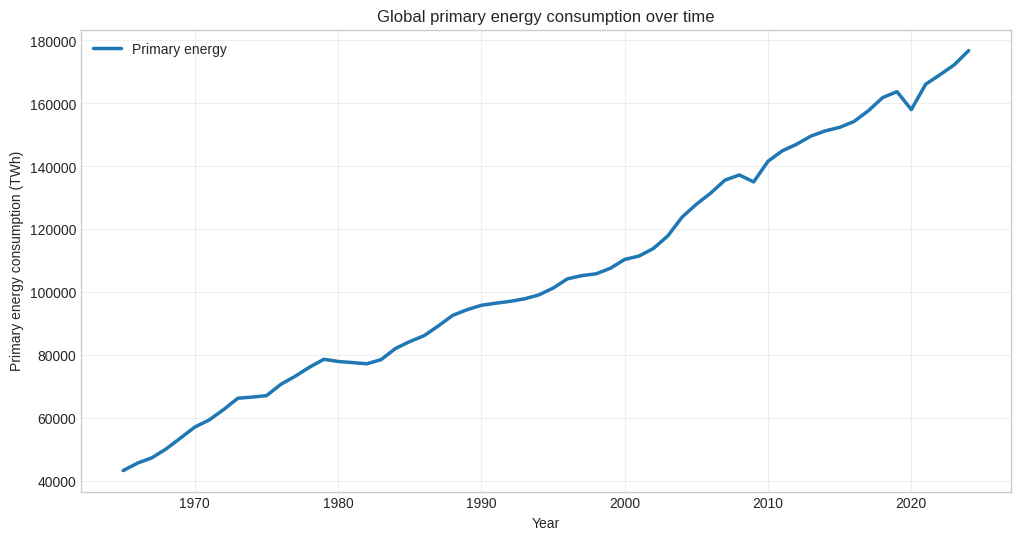

Earliest/latest valid years: 1965 / 2024
Values: 43,360.3 / 176,737.1 TWh
Absolute change: 133,376.8 TWh; percentage change: 307.6%


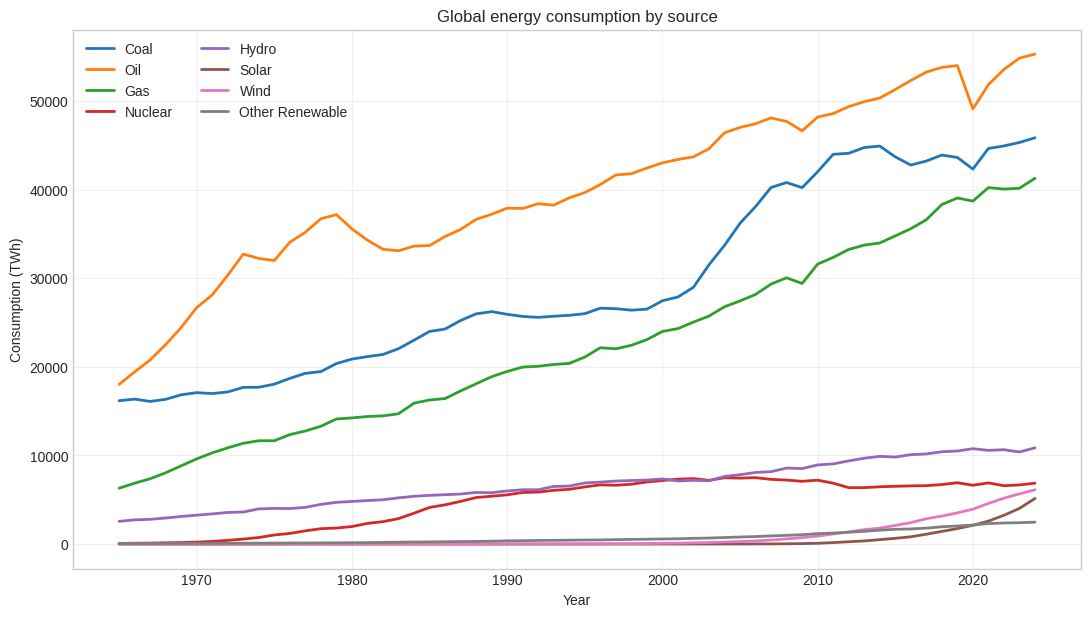

In [7]:
def global_series(metric):
    world = clean_df.loc[clean_df[entity_col].eq('World'), [year_col, metric]].dropna()
    if not world.empty:
        return world.sort_values(year_col).drop_duplicates(year_col)
    return country_df.groupby(year_col, as_index=False)[metric].sum(min_count=1)

energy_col = 'primary_energy_consumption'
if energy_col not in clean_df.columns:
    raise KeyError('The expected primary_energy_consumption column is not present.')
global_energy = global_series(energy_col)
display(global_energy.head()); display(global_energy.tail()); display(global_energy[energy_col].describe())
plt.figure(figsize=(12, 6))
plt.plot(global_energy[year_col], global_energy[energy_col], color='#1f77b4', linewidth=2.5, label='Primary energy')
plt.title('Global primary energy consumption over time'); plt.xlabel('Year'); plt.ylabel('Primary energy consumption (TWh)'); plt.legend(); plt.grid(alpha=.3); plt.show()
first, last = global_energy.iloc[0], global_energy.iloc[-1]
absolute_change = last[energy_col] - first[energy_col]
percent_change = absolute_change / first[energy_col] * 100 if first[energy_col] != 0 else np.nan
print(f'Earliest/latest valid years: {int(first[year_col])} / {int(last[year_col])}')
print(f'Values: {first[energy_col]:,.1f} / {last[energy_col]:,.1f} TWh')
print(f'Absolute change: {absolute_change:,.1f} TWh; percentage change: {percent_change:.1f}%')

source_cols = [c for c in ['coal_consumption','oil_consumption','gas_consumption','nuclear_consumption','hydro_consumption','solar_consumption','wind_consumption','other_renewable_consumption'] if c in clean_df.columns]
global_sources = pd.DataFrame({year_col: sorted(clean_df[year_col].unique())})
for col in source_cols:
    global_sources = global_sources.merge(global_series(col), on=year_col, how='left')
plt.figure(figsize=(13, 7))
for col in source_cols:
    plt.plot(global_sources[year_col], global_sources[col], linewidth=2, label=col.replace('_consumption','').replace('_',' ').title())
plt.title('Global energy consumption by source'); plt.xlabel('Year'); plt.ylabel('Consumption (TWh)'); plt.legend(ncol=2); plt.grid(alpha=.3); plt.show()

**Expected interpretation:** The printed values are the dataset-backed answer to the global-trend question. Read absolute growth alongside changes in the source mix: an increasing renewable line does not automatically mean fossil consumption has fallen.

## 8. Fossil fuels and renewable energy

Questions: How dependent is the world on fossil fuels? How are renewable sources changing? Country rankings use countries only and a single selected year.

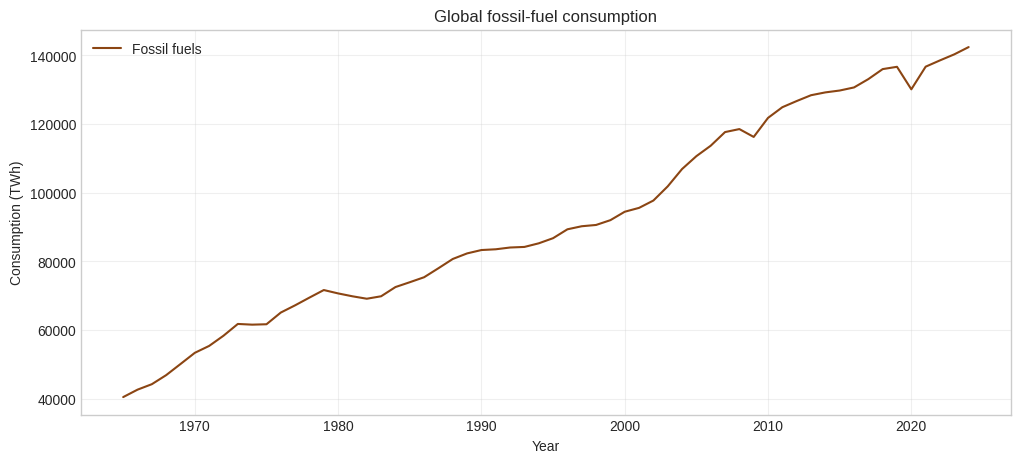

Fossil-energy share: 93.75% in 1965; 81.26% in 2024
Change: -12.49 percentage points


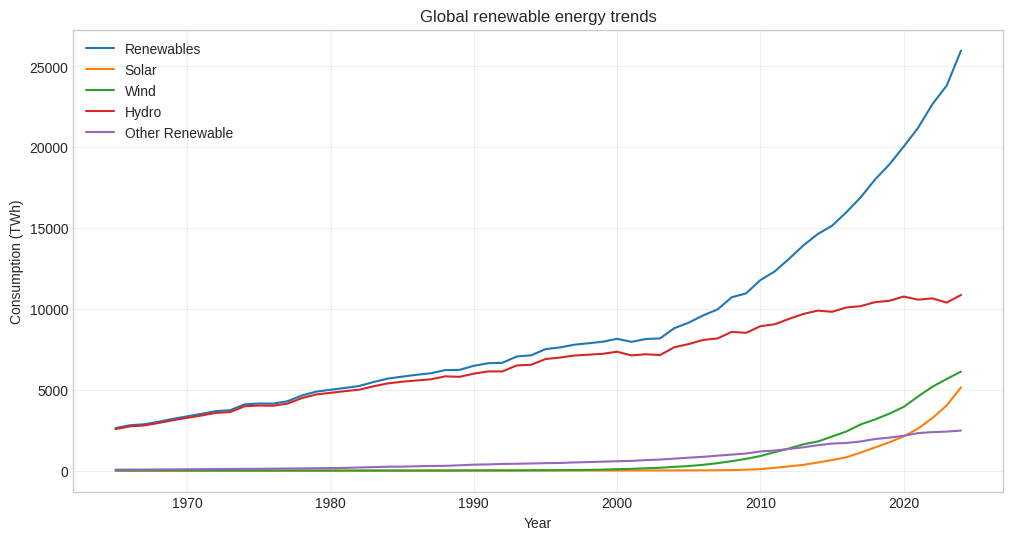

Growth over each series' available period: {'renewables_consumption': np.float64(887.918547889875), 'hydro_consumption': np.float64(323.5138008187783), 'other_renewable_consumption': np.float64(4306.026808833365)}
Largest percentage growth: other_renewable_consumption (4306.0%)


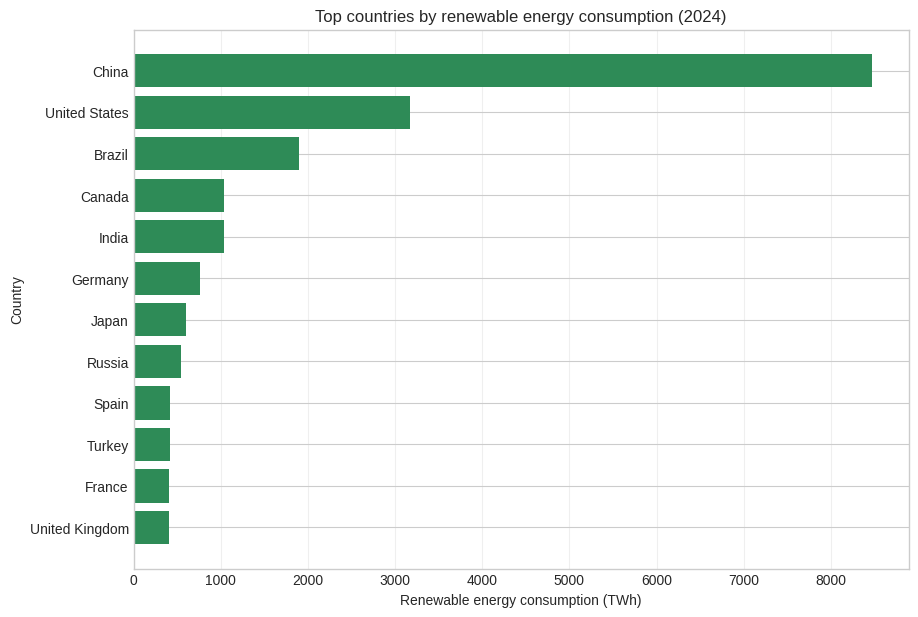

In [8]:
fossil_col = 'fossil_fuel_consumption' if 'fossil_fuel_consumption' in clean_df else None
renew_col = 'renewables_consumption' if 'renewables_consumption' in clean_df else None
share_col = 'fossil_share_energy' if 'fossil_share_energy' in clean_df else 'fossil_share_derived'
if fossil_col:
    fossil_global = global_series(fossil_col)
    plt.figure(figsize=(12, 5)); plt.plot(fossil_global[year_col], fossil_global[fossil_col], color='#8B4513', label='Fossil fuels')
    plt.title('Global fossil-fuel consumption'); plt.xlabel('Year'); plt.ylabel('Consumption (TWh)'); plt.legend(); plt.grid(alpha=.3); plt.show()
if share_col in clean_df.columns:
    fossil_share = global_series(share_col)
    print(f'Fossil-energy share: {fossil_share.iloc[0][share_col]:.2f}% in {int(fossil_share.iloc[0][year_col])}; {fossil_share.iloc[-1][share_col]:.2f}% in {int(fossil_share.iloc[-1][year_col])}')
    print(f'Change: {fossil_share.iloc[-1][share_col] - fossil_share.iloc[0][share_col]:.2f} percentage points')
if renew_col:
    renew_global = global_series(renew_col)
    renewable_cols = [c for c in ['renewables_consumption','solar_consumption','wind_consumption','hydro_consumption','other_renewable_consumption'] if c in clean_df]
    plt.figure(figsize=(12, 6))
    for col in renewable_cols:
        plt.plot(global_series(col)[year_col], global_series(col)[col], label=col.replace('_consumption','').replace('_',' ').title())
    plt.title('Global renewable energy trends'); plt.xlabel('Year'); plt.ylabel('Consumption (TWh)'); plt.legend(); plt.grid(alpha=.3); plt.show()
    growth = {}
    for col in renewable_cols:
        s = global_series(col)[col].dropna()
        if len(s) >= 2 and s.iloc[0] != 0: growth[col] = (s.iloc[-1]/s.iloc[0]-1)*100
    print("Growth over each series' available period:", growth)
    if growth: print('Largest percentage growth:', max(growth, key=growth.get), f'({max(growth.values()):.1f}%)')

ranking_year = int(country_df.loc[country_df[renew_col].notna(), year_col].max()) if renew_col else int(country_df[year_col].max())
if renew_col:
    top_renew = country_df.loc[country_df[year_col].eq(ranking_year), [entity_col, renew_col]].dropna().nlargest(12, renew_col).sort_values(renew_col)
    plt.figure(figsize=(10, 7)); plt.barh(top_renew[entity_col], top_renew[renew_col], color='#2E8B57')
    plt.title(f'Top countries by renewable energy consumption ({ranking_year})'); plt.xlabel('Renewable energy consumption (TWh)'); plt.ylabel('Country'); plt.grid(axis='x', alpha=.3); plt.show()

**Expected interpretation:** The fossil-share printout is a percentage-point comparison. Use it with absolute fossil consumption. The renewable chart and ranking demonstrate contribution according to specific indicators, not a complete measure of national sustainability.

## 9. Climate, GDP and energy relationships

This supplied version lacks direct CO₂ fields. The following cell uses `greenhouse_gas_emissions` when present and labels it as GHG emissions rather than CO₂. Correlations are descriptive only.

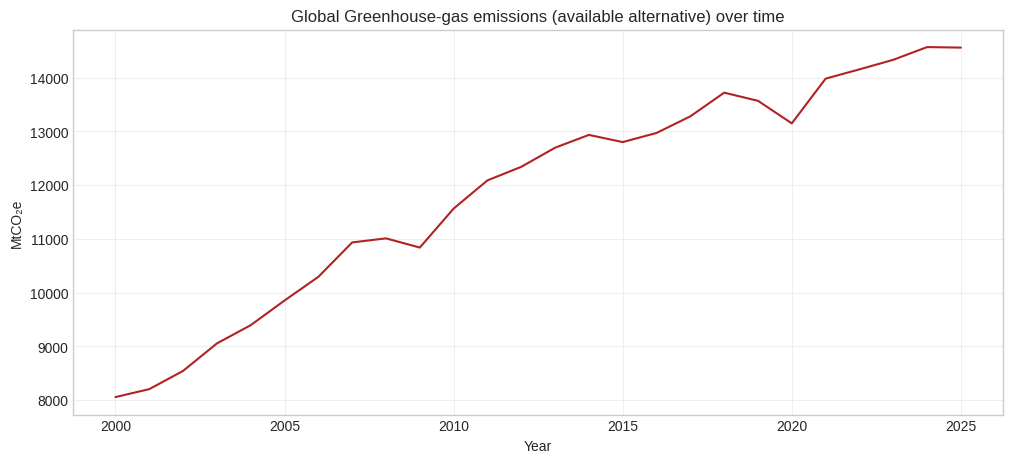

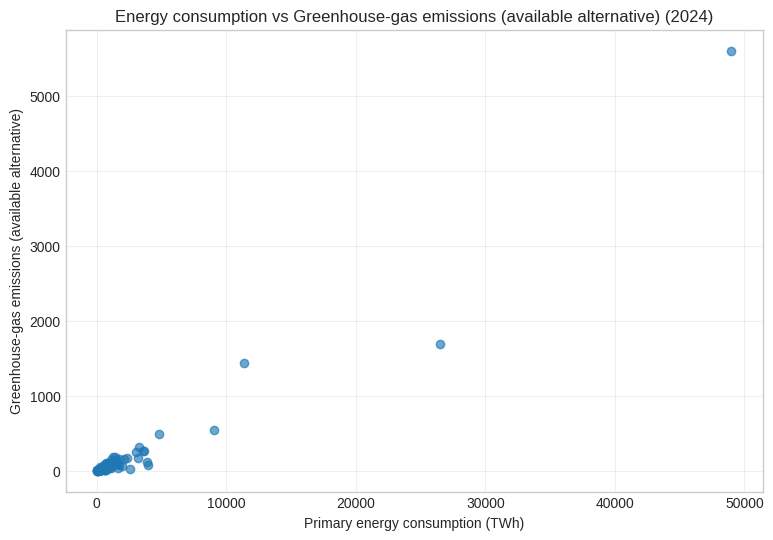

Pearson correlation: 0.973. This does not establish causation.


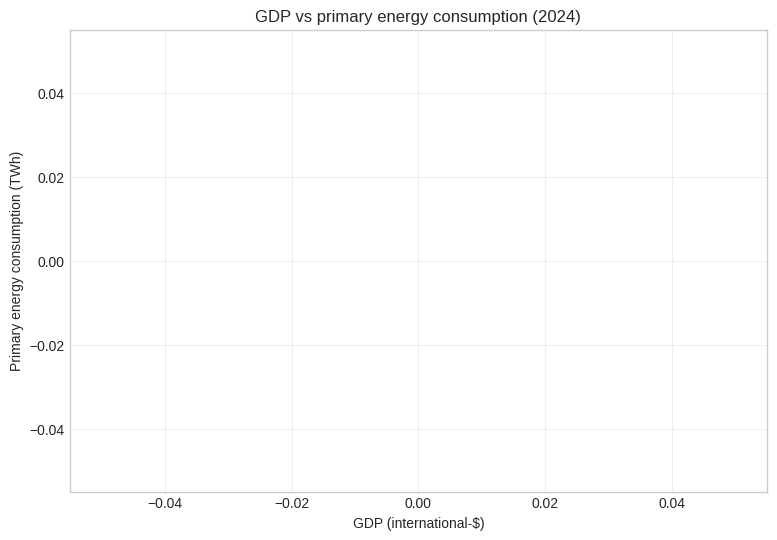

GDP–energy Pearson correlation: nan. Correlation does not imply causation.


,country,primary_energy_consumption,gdp
4606,China,48987.101562,NaN
21997,United States,26528.611328,NaN
9698,India,11336.056641,NaN
18158,Russia,9049.149414,NaN
10623,Japan,4794.816406,NaN


In [9]:
emissions_col = 'co2' if 'co2' in clean_df.columns else ('greenhouse_gas_emissions' if 'greenhouse_gas_emissions' in clean_df.columns else None)
emissions_label = 'CO₂ emissions' if emissions_col == 'co2' else 'Greenhouse-gas emissions (available alternative)'
comparison_year = int(country_df.loc[country_df[energy_col].notna(), year_col].max())
comparison_cols = [entity_col, energy_col] + [c for c in ['gdp','population','energy_per_capita','renewables_share_energy','fossil_share_energy', emissions_col] if c and c in country_df.columns]
comparison_df = country_df.loc[country_df[year_col].eq(comparison_year), comparison_cols].copy()

if emissions_col:
    emissions_global = global_series(emissions_col)
    plt.figure(figsize=(12, 5)); plt.plot(emissions_global[year_col], emissions_global[emissions_col], color='#B22222')
    plt.title(f'Global {emissions_label} over time'); plt.xlabel('Year'); plt.ylabel('MtCO₂e' if emissions_col == 'greenhouse_gas_emissions' else 'Emissions'); plt.grid(alpha=.3); plt.show()
    emission_energy = comparison_df[[energy_col, emissions_col]].dropna()
    corr = emission_energy[energy_col].corr(emission_energy[emissions_col])
    plt.figure(figsize=(9, 6)); plt.scatter(emission_energy[energy_col], emission_energy[emissions_col], alpha=.65)
    plt.title(f'Energy consumption vs {emissions_label} ({comparison_year})'); plt.xlabel('Primary energy consumption (TWh)'); plt.ylabel(emissions_label); plt.grid(alpha=.3); plt.show()
    print(f'Pearson correlation: {corr:.3f}. This does not establish causation.')
else:
    print('No direct CO₂ or GHG emissions column is available; this analysis is skipped rather than fabricated.')

if 'gdp' in comparison_df:
    gdp_energy = comparison_df[['gdp', energy_col]].dropna()
    gdp_corr = gdp_energy['gdp'].corr(gdp_energy[energy_col])
    plt.figure(figsize=(9, 6)); plt.scatter(gdp_energy['gdp'], gdp_energy[energy_col], alpha=.65, color='#4169E1')
    plt.title(f'GDP vs primary energy consumption ({comparison_year})'); plt.xlabel('GDP (international-$)'); plt.ylabel('Primary energy consumption (TWh)'); plt.grid(alpha=.3); plt.show()
    print(f'GDP–energy Pearson correlation: {gdp_corr:.3f}. Correlation does not imply causation.')
    display(comparison_df.nlargest(5, energy_col)[[entity_col, energy_col, 'gdp']])

**Expected interpretation:** Countries with high total energy use may tend to report high total emissions, but energy mix, industry composition and reporting coverage also matter. GDP and energy use may move together without one variable alone causing the other.

## 10. Country comparisons, rankings and energy per capita

Use the latest common year for selected countries so no country receives an unfair advantage from a newer observation. Total and per-capita measures answer different questions.

Selected countries: ['India', 'China', 'United States', 'Germany', 'Japan', 'United Kingdom', 'France']
Latest common year: 2025


,country,year,primary_energy_consumption,energy_per_capita,renewables_consumption,fossil_share_energy,greenhouse_gas_emissions
4607,China,2025,NaN,NaN,NaN,NaN,5559.879883
7811,France,2025,NaN,NaN,NaN,NaN,23.620001
8282,Germany,2025,NaN,NaN,NaN,NaN,164.979996
9699,India,2025,NaN,NaN,NaN,NaN,1394.949951
10624,Japan,2025,NaN,NaN,NaN,NaN,491.510010
21872,United Kingdom,2025,NaN,NaN,NaN,NaN,63.549999
21998,United States,2025,NaN,NaN,NaN,NaN,1737.420044


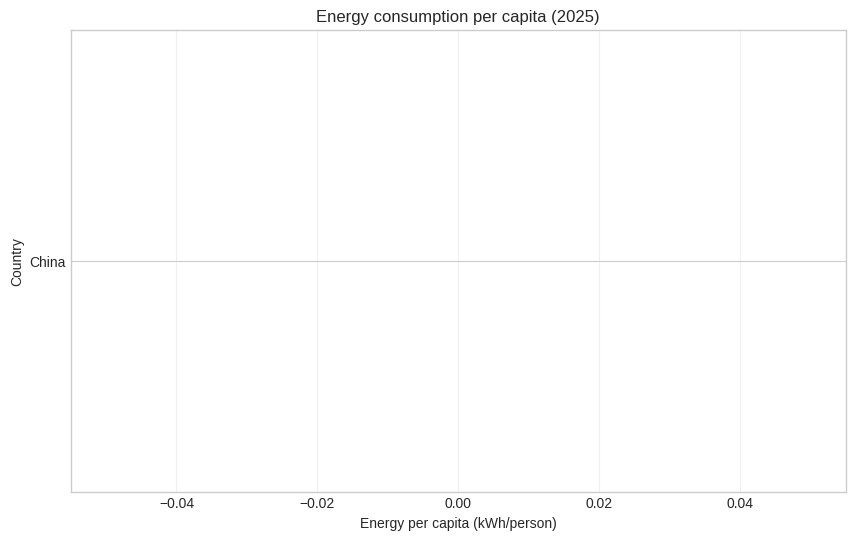

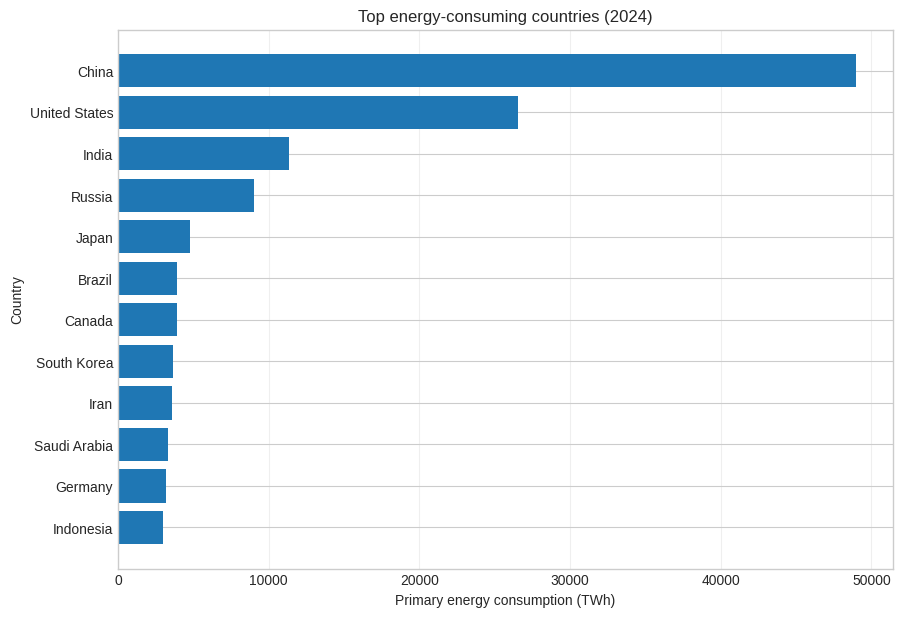

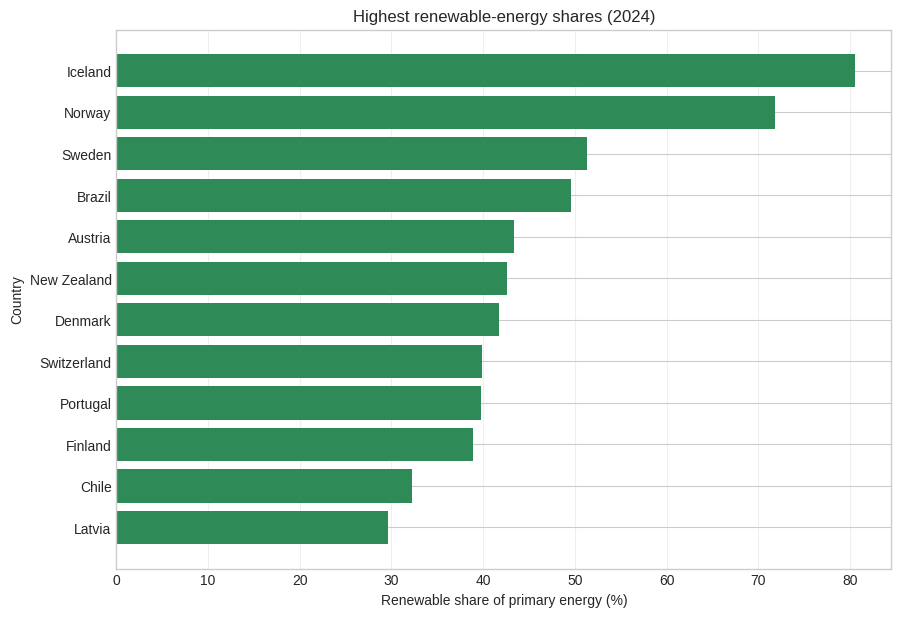

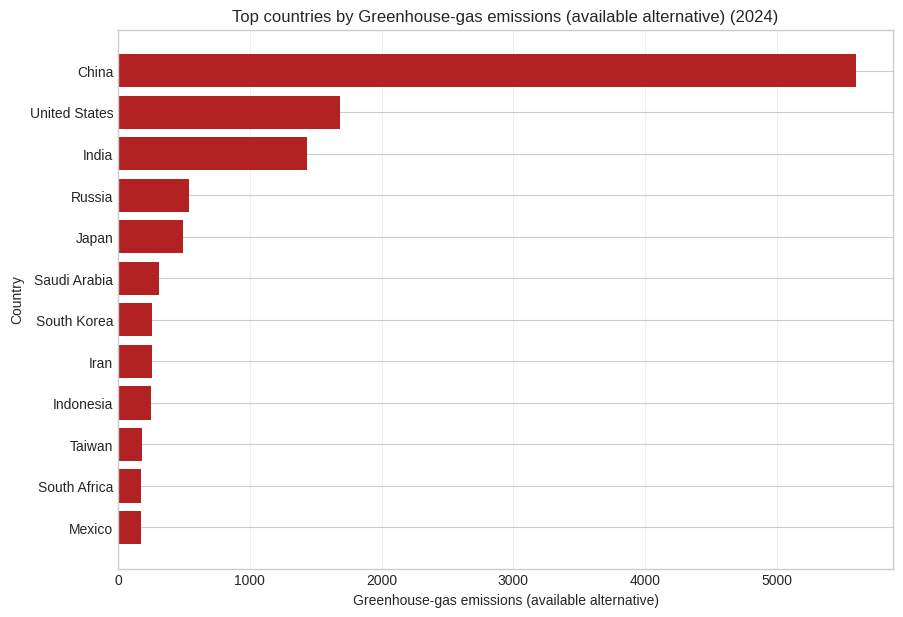

CO₂-per-capita ranking is not produced because this CSV lacks a direct CO₂ measure with documented compatible units.


In [10]:
selected_countries = [c for c in ['India','China','United States','Germany','Japan','United Kingdom','France'] if c in set(country_df[entity_col])]
metrics_for_common_year = [energy_col] + [c for c in ['energy_per_capita','renewables_consumption','fossil_share_energy', emissions_col] if c and c in country_df]
candidate = country_df.loc[country_df[entity_col].isin(selected_countries), [entity_col, year_col] + metrics_for_common_year]
common_years = candidate.groupby(year_col)[entity_col].nunique()
common_year = int(common_years[common_years.eq(len(selected_countries))].index.max())
peer_df = candidate.loc[candidate[year_col].eq(common_year)].copy()
print('Selected countries:', selected_countries); print('Latest common year:', common_year)
display(peer_df)

if 'energy_per_capita' in peer_df:
    ordered = peer_df.sort_values('energy_per_capita')
    plt.figure(figsize=(10, 6)); plt.barh(ordered[entity_col], ordered['energy_per_capita'], color='#6A5ACD')
    plt.title(f'Energy consumption per capita ({common_year})'); plt.xlabel('Energy per capita (kWh/person)'); plt.ylabel('Country'); plt.grid(axis='x', alpha=.3); plt.show()

top_energy = country_df.loc[country_df[year_col].eq(comparison_year), [entity_col, energy_col]].dropna().nlargest(12, energy_col).sort_values(energy_col)
plt.figure(figsize=(10, 7)); plt.barh(top_energy[entity_col], top_energy[energy_col], color='#1f77b4')
plt.title(f'Top energy-consuming countries ({comparison_year})'); plt.xlabel('Primary energy consumption (TWh)'); plt.ylabel('Country'); plt.grid(axis='x', alpha=.3); plt.show()

if 'renewables_share_energy' in country_df:
    top_share = country_df.loc[country_df[year_col].eq(comparison_year), [entity_col,'renewables_share_energy']].dropna().nlargest(12,'renewables_share_energy').sort_values('renewables_share_energy')
    plt.figure(figsize=(10, 7)); plt.barh(top_share[entity_col], top_share['renewables_share_energy'], color='#2E8B57')
    plt.title(f'Highest renewable-energy shares ({comparison_year})'); plt.xlabel('Renewable share of primary energy (%)'); plt.ylabel('Country'); plt.grid(axis='x', alpha=.3); plt.show()
if emissions_col:
    top_emissions = country_df.loc[country_df[year_col].eq(comparison_year), [entity_col,emissions_col]].dropna().nlargest(12,emissions_col).sort_values(emissions_col)
    plt.figure(figsize=(10, 7)); plt.barh(top_emissions[entity_col], top_emissions[emissions_col], color='#B22222')
    plt.title(f'Top countries by {emissions_label} ({comparison_year})'); plt.xlabel(emissions_label); plt.ylabel('Country'); plt.grid(axis='x', alpha=.3); plt.show()
if 'co2_per_capita' not in clean_df.columns:
    print('CO₂-per-capita ranking is not produced because this CSV lacks a direct CO₂ measure with documented compatible units.')

**Expected interpretation:** Compare total energy use with energy per person separately. A populous country can rank highly in total consumption while having a lower per-capita value. CO₂-per-capita rankings are intentionally omitted when the source field is unavailable.

## 11. India: Energy Transition

Track India across time and compare peers using clearly defined indicators. No country is labelled ‘better’; each metric measures a different aspect of an energy system.

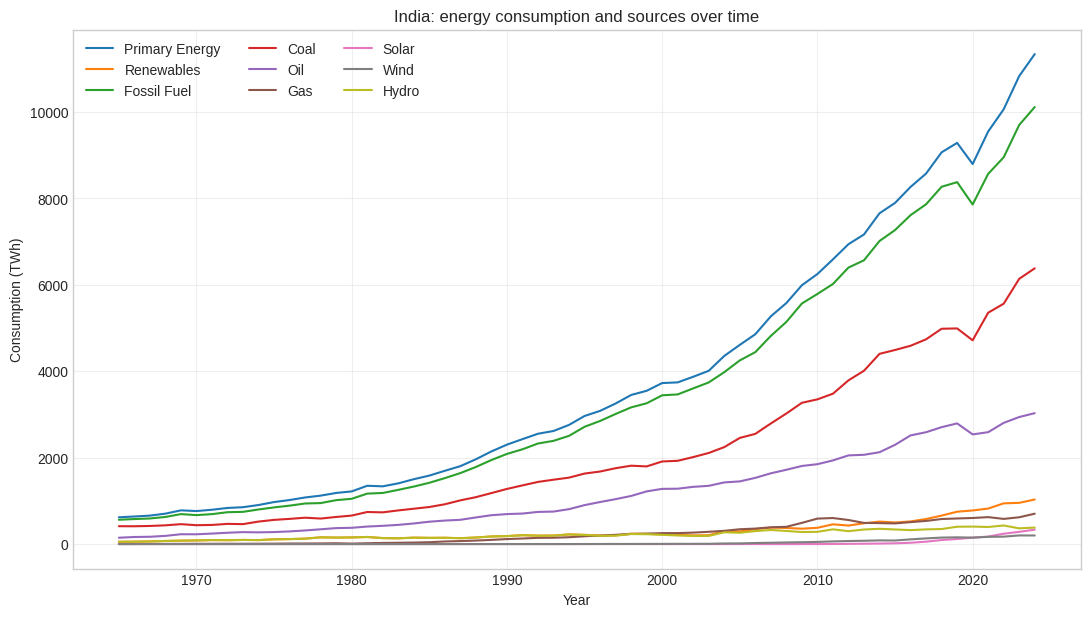

,year,renewables_share_energy,fossil_share_energy,energy_per_capita
9690,2016,6.369765,92.473145,6148.213379
9691,2017,6.792767,92.111275,6304.287109
9692,2018,7.307381,91.615967,6593.169434
9693,2019,8.108068,90.681297,6682.067871
9694,2020,8.892713,89.847481,6268.436523
9695,2021,8.656782,90.204025,6749.358398
9696,2022,9.421208,89.444290,7057.186523
9697,2023,8.860951,90.047241,7529.440430
9698,2024,9.146443,89.670319,7812.927734
9699,2025,NaN,NaN,NaN


India primary_energy_consumption: 1730.0% change from 1965 to 2024
India renewables_consumption: 1837.2% change from 1965 to 2024
India fossil_fuel_consumption: 1696.7% change from 1965 to 2024
India greenhouse_gas_emissions: 229.9% change from 2000 to 2025


In [11]:
india = clean_df.loc[clean_df[entity_col].eq('India')].sort_values(year_col).copy()
if india.empty:
    print('India is not available in this dataset.')
else:
    india_metrics = [c for c in ['primary_energy_consumption','renewables_consumption','fossil_fuel_consumption','coal_consumption','oil_consumption','gas_consumption','solar_consumption','wind_consumption','hydro_consumption'] if c in india]
    plt.figure(figsize=(13, 7))
    for col in india_metrics:
        plt.plot(india[year_col], india[col], label=col.replace('_consumption','').replace('_',' ').title())
    plt.title('India: energy consumption and sources over time'); plt.xlabel('Year'); plt.ylabel('Consumption (TWh)'); plt.legend(ncol=3); plt.grid(alpha=.3); plt.show()
    india_share = [c for c in ['renewables_share_energy','fossil_share_energy','energy_per_capita'] if c in india]
    display(india[[year_col] + india_share].tail(10))
    for col in ['primary_energy_consumption','renewables_consumption','solar_consumption','fossil_fuel_consumption', emissions_col]:
        if col and col in india:
            s = india[[year_col,col]].dropna()
            if len(s) >= 2 and s.iloc[0][col] != 0:
                print(f'India {col}: {((s.iloc[-1][col]/s.iloc[0][col]-1)*100):.1f}% change from {int(s.iloc[0][year_col])} to {int(s.iloc[-1][year_col])}')

**Expected interpretation:** Use the dynamically printed India trends together with the peer chart. Renewable growth, fossil use, total demand and per-capita energy are distinct indicators and should not be collapsed into one judgement.

## 12. Correlation, time-series statistics and outliers

Use a focused correlation matrix and IQR screening to identify patterns worth investigating. Outliers can be real country characteristics, not data errors.

,population,gdp,primary_energy_consumption,energy_per_capita,renewables_share_energy,greenhouse_gas_emissions
population,1.00,NaN,0.78,-0.15,-0.08,0.83
gdp,NaN,NaN,NaN,NaN,NaN,NaN
primary_energy_consumption,0.78,NaN,1.00,0.02,-0.06,0.97
energy_per_capita,-0.15,NaN,0.02,1.00,0.04,-0.02
renewables_share_energy,-0.08,NaN,-0.06,0.04,1.00,-0.07
greenhouse_gas_emissions,0.83,NaN,0.97,-0.02,-0.07,1.00


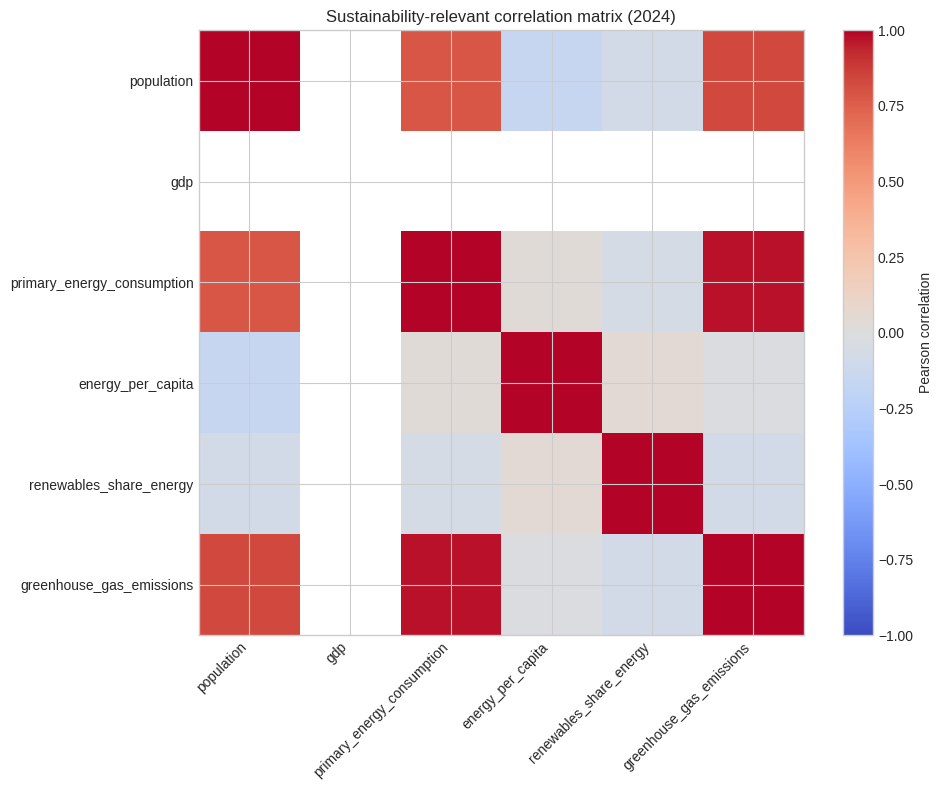

IQR method: Q1=19477.1, Q3=50174.7, IQR=30697.5, lower=-26569.2, upper=96221.0


,country,energy_per_capita
17917,Qatar,214520.296875
18886,Singapore,180701.453125
9573,Iceland,159676.390625
21746,United Arab Emirates,138026.484375
10952,Kuwait,106398.593750
20899,Trinidad and Tobago,105988.437500
15169,Norway,99634.312500
3939,Canada,97784.539062
18641,Saudi Arabia,96883.312500


primary_energy_consumption: absolute change=133,376.8, percentage change=307.6%, mean annual % change=2.43%
renewables_consumption: absolute change=23,349.4, percentage change=887.9%, mean annual % change=3.99%
fossil_fuel_consumption: absolute change=101,927.9, percentage change=251.7%, mean annual % change=2.18%


In [12]:
correlation_columns = [c for c in ['population','gdp','primary_energy_consumption','energy_per_capita','renewables_consumption','fossil_fuel_consumption','renewables_share_energy', emissions_col] if c and c in comparison_df]
correlation_matrix = comparison_df[correlation_columns].corr(numeric_only=True)
display(correlation_matrix.round(2))
plt.figure(figsize=(10, 8)); plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Pearson correlation'); plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha='right'); plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title(f'Sustainability-relevant correlation matrix ({comparison_year})'); plt.tight_layout(); plt.show()

if 'energy_per_capita' in comparison_df:
    values = comparison_df['energy_per_capita'].dropna()
    q1, q3 = values.quantile(.25), values.quantile(.75); iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = comparison_df.loc[(comparison_df['energy_per_capita'] < lower) | (comparison_df['energy_per_capita'] > upper), [entity_col,'energy_per_capita']]
    print(f'IQR method: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}, lower={lower:.1f}, upper={upper:.1f}')
    display(outliers.sort_values('energy_per_capita', ascending=False))

for col in [energy_col, renew_col, fossil_col]:
    if col:
        s = global_series(col).dropna()
        change = s.iloc[-1][col] - s.iloc[0][col]
        pct = change / s.iloc[0][col] * 100 if s.iloc[0][col] != 0 else np.nan
        annual_changes = s.sort_values(year_col)[col].pct_change().replace([np.inf,-np.inf], np.nan).dropna() * 100
        print(f'{col}: absolute change={change:,.1f}, percentage change={pct:.1f}%, mean annual % change={annual_changes.mean():.2f}%')

**Expected interpretation:** Focus on a few meaningful relationships, such as GDP–energy or energy–emissions. IQR flags observations for context, not automatic deletion. Correlation does not establish causal direction.

## 13. Key findings, sustainability interpretation, limitations and conclusion

This final cell produces data-backed findings rather than hardcoded claims. Edit the surrounding prose only after reviewing the numbers printed in your own run.

In [13]:
def change_statement(series, col, label):
    s = series[[year_col, col]].dropna()
    if len(s) < 2 or s.iloc[0][col] == 0: return f'{label}: insufficient data for a change calculation.'
    pct = (s.iloc[-1][col] / s.iloc[0][col] - 1) * 100
    return f'{label} changed {pct:.1f}% from {int(s.iloc[0][year_col])} to {int(s.iloc[-1][year_col])}.'

findings = [change_statement(global_energy, energy_col, 'Global primary energy consumption')]
if renew_col: findings.append(change_statement(global_series(renew_col), renew_col, 'Global renewable energy consumption'))
if fossil_col: findings.append(change_statement(global_series(fossil_col), fossil_col, 'Global fossil-fuel consumption'))
if share_col in clean_df: findings.append(change_statement(global_series(share_col), share_col, 'Global fossil-energy share'))
if emissions_col: findings.append(change_statement(global_series(emissions_col), emissions_col, f'Global {emissions_label}'))
if 'energy_per_capita' in peer_df:
    per_capita_peers = peer_df.dropna(subset=['energy_per_capita'])
    if not per_capita_peers.empty:
        highest = per_capita_peers.loc[per_capita_peers['energy_per_capita'].idxmax()]
        findings.append(f"Among selected economies in {common_year}, {highest[entity_col]} has the highest energy per capita ({highest['energy_per_capita']:,.0f} kWh/person).")
    else:
        findings.append(f'Energy-per-capita data are unavailable for the selected economies in the latest common year ({common_year}).')
if 'renewables_share_energy' in country_df:
    renewable_records = country_df.loc[country_df[year_col].eq(comparison_year)].dropna(subset=['renewables_share_energy'])
    if not renewable_records.empty:
        record = renewable_records.nlargest(1,'renewables_share_energy').iloc[0]
        findings.append(f"In {comparison_year}, {record[entity_col]} has the highest country-level renewable-energy share in this dataset ({record['renewables_share_energy']:.1f}%).")
print('KEY FINDINGS')
for i, finding in enumerate(findings, 1): print(f'{i}. {finding}')

print('\nSUSTAINABILITY INTERPRETATION')
print('Growing renewables can support SDG 7 and reduce exposure to fossil energy, but absolute fossil consumption and total demand must be examined alongside shares.')
print('Climate indicators provide SDG 13 context. They are not proof that one energy variable causes emissions outcomes, because energy mix, economic structure and reporting differ.')
print('\nLIMITATIONS')
print('Missing values indicate unavailable observations; country coverage and reporting methods vary by measure and year. Aggregates must not be mixed with countries in rankings. Correlation is not causation. This CSV lacks direct CO₂ and CO₂-per-capita fields, so those analyses are not fabricated.')
print('\nCONCLUSION')
print('The dataset supports a nuanced view of energy transition: renewable deployment, fossil dependence, energy demand and reported climate indicators need to be interpreted together and with transparent data limitations.')
print('\nDATA SOURCE')
print('Our World in Data — Energy Dataset. https://ourworldindata.org/energy (accessed when this notebook is run). OWID compiles data from multiple original sources; consult its documentation for definitions and methodology.')

KEY FINDINGS
1. Global primary energy consumption changed 307.6% from 1965 to 2024.
2. Global renewable energy consumption changed 887.9% from 1965 to 2024.
3. Global fossil-fuel consumption changed 251.7% from 1965 to 2024.
4. Global fossil-energy share changed -13.3% from 1965 to 2024.
5. Global Greenhouse-gas emissions (available alternative) changed 80.7% from 2000 to 2025.
6. Energy-per-capita data are unavailable for the selected economies in the latest common year (2025).
7. In 2024, Iceland has the highest country-level renewable-energy share in this dataset (80.5%).

SUSTAINABILITY INTERPRETATION
Growing renewables can support SDG 7 and reduce exposure to fossil energy, but absolute fossil consumption and total demand must be examined alongside shares.
Climate indicators provide SDG 13 context. They are not proof that one energy variable causes emissions outcomes, because energy mix, economic structure and reporting differ.

LIMITATIONS
Missing values indicate unavailable obse